# Exercise 1: DCT Smoothing and B-spline Interpolation

### Introduction

This exercise is about smoothing and interpolating medical images using discrete cosine transforms and B-spline basis functions. 

<StemContainer object of 3 artists>

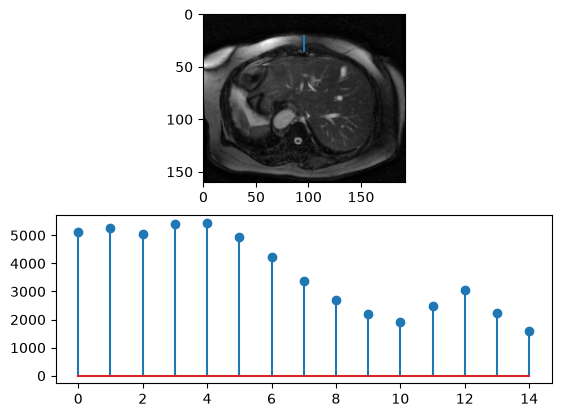

In [62]:
import numpy as np
np.set_printoptions( suppress=True )

from matplotlib import pyplot as plt

plt.ion()
fileName = 'AbdomenMRCT_0003_0000.nii.gz'

import nibabel as nib

data = nib.load(fileName).get_fdata()
T = np.flipud(data[:, :, 130].T)
N1, N2 = T.shape
fix, ax = plt.subplots(2, 1)
ax[0].imshow(T, cmap='gray')
t_range = [21, 35]
ax[0].plot([N2//2]*2, t_range)  # this indicates the 1D snippet in the 2D image
t = T[t_range[0]:t_range[1]+1, N2//2]
N = t.size
ax[1].stem(t)

## Task 1: Smoothing in 1D
### Task 1a:
Using the first $M=3$ DCT basis functions defined in the book, smooth $\mathbf{t}$ to obtain $\hat{\mathbf{t}}$, and display the result.  
For the middle element of $\hat{\mathbf{t}}$ , illustrate how its value is computed as a weighted sum of the elements in $\mathbf{t}$.  
Also compute this weighted sum explicitly, and verify that it is indeed identical to the middle element of $\hat{\mathbf{t}}$.

The weighted sum of elements in t correspnds to tHat! (weightedSum:  3569.1665498547177  // tHat[7]:  3569.1665498547177 )


<Figure size 1000x600 with 0 Axes>

<Figure size 800x500 with 0 Axes>

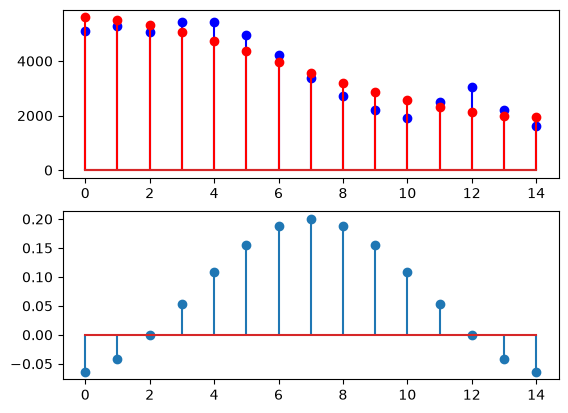

In [63]:
# your code goes here
len(t), N//2
phi = np.empty([len(t), 3])
for i in range(len(t)):
    for j in range(3):
        phi[i][j] = np.cos(np.pi*j*(i + 1/2)/len(t))
        if j == 0:
            phi[i][j] /= np.sqrt(2)
phi
plt.figure(figsize=(10, 6))
#for j in range(phi.shape[1]):
    #plt.plot(phi[:, j])
#plt.show()

tPhi = phi.transpose()
S = np.matmul(tPhi, phi)
S = np.matmul(phi, np.linalg.inv(S))
S = np.matmul(S, tPhi)

tSummed = S[7, :] * t
plt.figure(figsize=(8, 5))

tHat = np.matmul(S, t)

fix, ax = plt.subplots(2, 1)
ax[0].stem(t, linefmt='b-')
ax[0].stem(tHat, linefmt='r-')
ax[1].stem(S[7,:])

weightedSum = 0
for i in range(len(tSummed)):
    weightedSum += tSummed[i]
    
if abs(weightedSum - tHat[7]) < 0.0036:
    print("The weighted sum of elements in t correspnds to tHat! (weightedSum: ", weightedSum, " // tHat[7]: ", tHat[7], ")")


### Task 1b:
Repeat the previous task, but this time using M=7 basis functions. Discuss the resulting differences.

## Task 2: Smoothing in 2D
### Task 2a:
Using $M=7$ DCT basis functions for both directions, construct the resulting 2D DCT basis functions ($7*7=49$ in total) using the Kronecker product.  
Smooth the image using these basis functions by vectorizing it first, performing the computations in 1D, and un-vectorizing the result back into 2D.
Also display the 49 basis functions as 2D images.

Hints:
- `np.kron()` implements the Kronecker product
- `t = T.reshape(-1, 1, order='F')` will vectorize `T`
- `T = t.reshape(N1, N2, order='F')` will un-vectorize `t`


### Task 2b:
Repeat the smoothing operation, but now exploiting the separability of the
basis functions. Verify that the result obtained this way is identical (up to small 
numerical errors) to the previously obtained result.


## Task 3: Interpolation in 1D
### Task 3a:
Implement a function that evaluates a standard B-spline of order 0, 1 and 3 at arbitrary locations.  
Use this function to draw the B-splines of these orders over the interval $[-3, 3]$


In [64]:
# B-spline function

def b_spline(x, k):

    # Order 0
    if k == 0:
        if -0.5 <= x < 0.5:
            return 1
        elif np.abs(x) == 0.5:
            return 0.5
        else:
            return 0
    # Order 1
    elif k == 1:
        if -1 <= x < 0:
            return x + 1
        elif 0 <= x < 1:
            return -x + 1
        else:
            return 0
    # Order 3
    elif k == 3:
        if np.abs(x) < 1:
            return (2/3-np.abs(x)**2 + 0.5*np.abs(x)**3)
        elif 1 <= np.abs(x) < 2:
            return (1/6)*(2-np.abs(x))**3
        else:
            return 0
    else:
        raise ValueError("Unsupported B-spline order. Only k=0,1,3 are supported.")

In this cell, we define the B-spline basis functions that will be used for the interpolation tasks throughout the assignment. The functions are implemented using a case by case definition based on the mathematical formulas presented in the lecture slides and the course book.

**B-spline of order 0 (Nearest neighbour)**

$$
\beta^{0}(x)=
\begin{cases}
1, & -\frac{1}{2}<x<\frac{1}{2},\\[4pt]
\frac{1}{2}, & |x|=\frac{1}{2},\\[4pt]
0, & \text{otherwise}.
\end{cases}
$$

**B-spline of order 1 (Linear)**

$$
\beta^{1}(x)=
\begin{cases}
1-|x|, & |x|<1,\\[4pt]
0, & \text{otherwise}.
\end{cases}
$$

**B-spline of order 3 (Cubic)**

$$
\beta^{3}(x)=
\begin{cases}
\frac{2}{3}-|x|^{2}+\frac{|x|^{3}}{2}, & |x|<1,\\[8pt]
\frac{(2-|x|)^{3}}{6}, & 1\le |x|<2,\\[8pt]
0, & \text{otherwise}.
\end{cases}
$$

In the following cell, we use the implemented B-spline function to plot B-splines of orders 0, 1, and 3 over the interval $[-3,3]$. The plots illustrate the shape of each basis function: first the order-0, followed by the order-1, and finally the order-3.

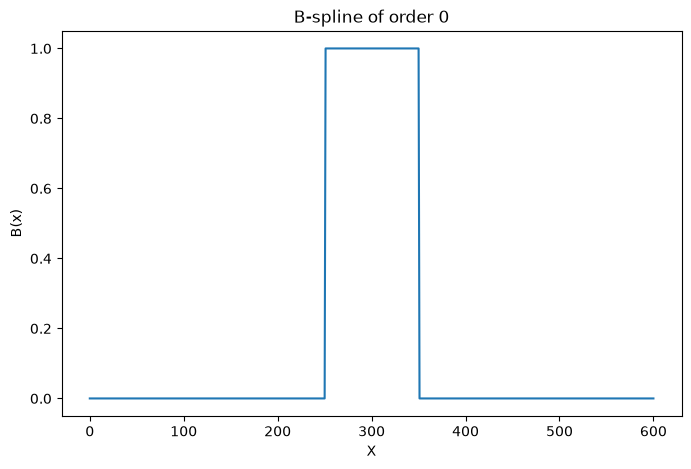

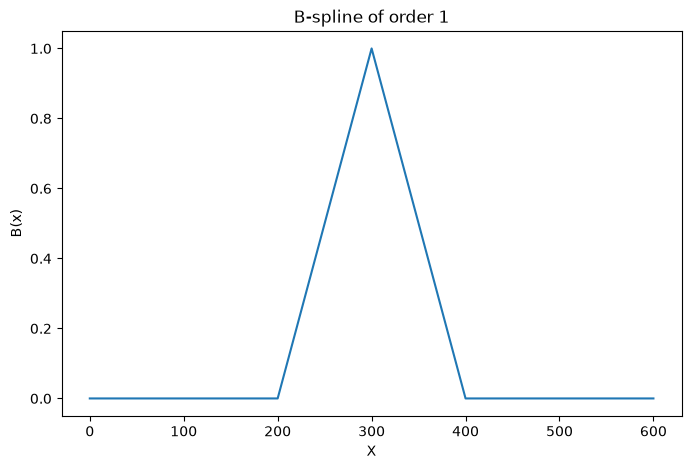

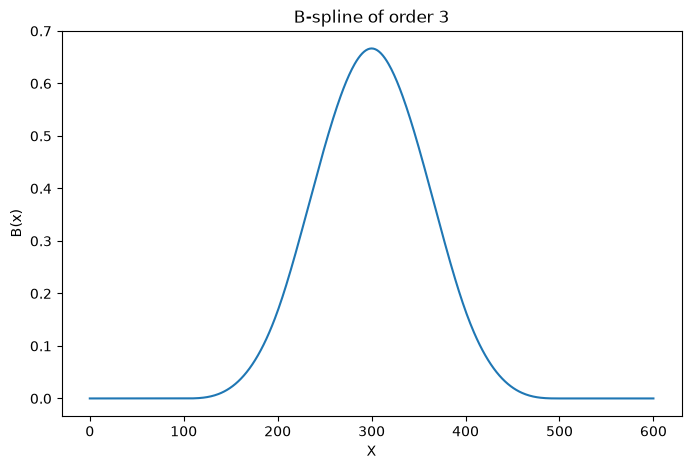

In [65]:
# B-spline interval [-3,3]
dx = 0.01
i = -3
b_0 = []
b_1 = []
b_3 = []

while i < 3:
    b_0.append(b_spline(i, 0))
    b_1.append(b_spline(i, 1))
    b_3.append(b_spline(i, 3))
    i += dx

# Plot B-spline of order 0
plt.figure(figsize=(8, 5))
plt.plot(b_0, label='B(x, 0)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 0')
plt.show()

# Plot B-spline of order 1
plt.figure(figsize=(8, 5))
plt.plot(b_1, label='B(x, 1)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 1')
plt.show()

# Plot B-spline of order 3
plt.figure(figsize=(8, 5))
plt.plot(b_3, label='B(x, 3)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 3')
plt.show()

### Task 3b:
Interpolate $\mathbf{t}$ at the non-integer locations `x_interp` defined below, using B-splines of order 0, 1 and 3.
For each order, plot the resulting curve along with the original points in $\mathbf{t}$.

To complete this task, we followed the same procedure for all three B-spline orders (0, 1, and 3), which is the following:

First, we initialized the basis matrix $\Phi$, which contains the values of all shifted B-spline basis functions evaluated at the sample locations. Then, using two nested `for` loops, we filled the matrix by evaluating the B-spline for every combination of sample position $i$ and basis function $j$.

Next, we computed the interpolation weights by solving the linear system

$$
\mathbf{w} = \Phi^{-1}\mathbf{t},
$$

where $\mathbf{t}$ is the vector containing the known signal samples.

Finally, we reconstructed the interpolated signal as a linear combination of the weighted B-spline basis functions. For each interpolation point $x$, the signal is evaluated as multiplying each basis function by its corresponding weight, and summing all contributions. The mathematical formula is:

$$
y(x)=\sum_{j=0}^{N-1} w_j\,\beta^{p}(x-j).
$$

The resulting signal approximation is then plotted for each B-spline order.

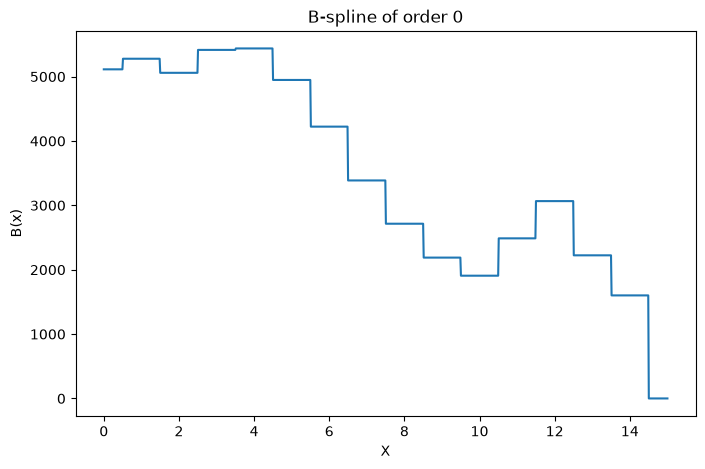

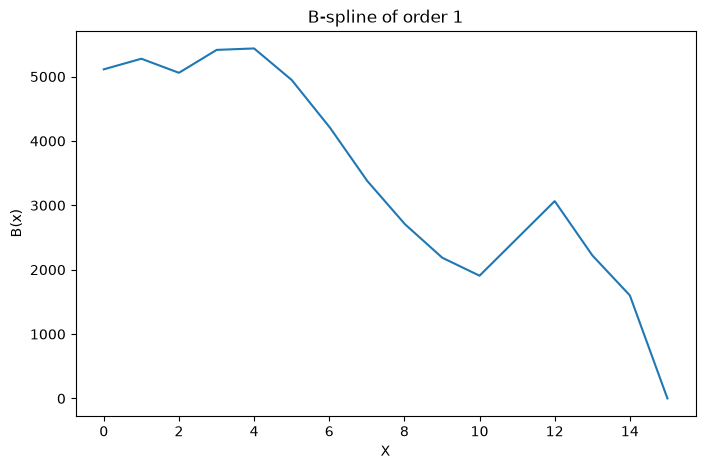

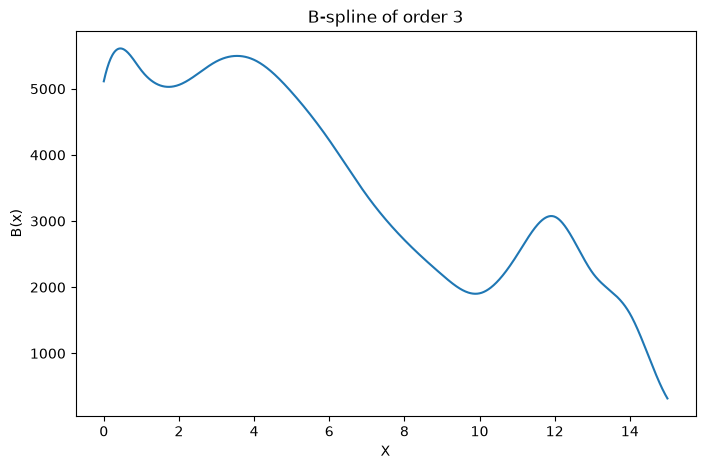

In [66]:
x_interp = np.linspace(0, N, 1000)

# Create the phi matrix for B-spline of order 0
phi_0 = np.zeros((N, N))

# Fill the phi matrix
for i in range(N):
    for j in range(N):
        phi_0[i][j] = b_spline(i - j, 0)

# Compute weights for B-spline of order 0
weights_0 = np.linalg.inv(phi_0) @ t
y_0 = np.zeros_like(x_interp)

# Compute the signal approximation using B-spline of order 0
for i in range(1000):
    for j in range(N):
        y_0[i] += weights_0[j] * b_spline(x_interp[i] - j, 0)

# Plot signal approximation using B-spline of order 0
plt.figure(figsize=(8, 5))
plt.plot(x_interp, y_0, label='B(x, 0)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 0')
plt.show()


# Same process for B-spline of order 1
phi_1 = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        phi_1[i][j] = b_spline(i - j, 1)

weights_1 = np.linalg.inv(phi_1) @ t
y_1 = np.zeros_like(x_interp)
for i in range(1000):
    for j in range(N):
        y_1[i] += weights_1[j] * b_spline(x_interp[i] - j, 1)

# Plot signal approximation using B-spline of order 1
plt.figure(figsize=(8, 5))
plt.plot(x_interp, y_1, label='B(x, 1)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 1')
plt.show()


# Same process for B-spline of order 3
phi_3 = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        phi_3[i][j] = b_spline(i - j, 3)

weights_3 = np.linalg.inv(phi_3) @ t
y_3 = np.zeros_like(x_interp)
for i in range(1000):
    for j in range(N):
        y_3[i] += weights_3[j] * b_spline(x_interp[i] - j, 3)

# Plot signal approximation using B-spline of order 3
plt.figure(figsize=(8, 5))
plt.plot(x_interp, y_3, label='B(x, 3)')
plt.xlabel('X')
plt.ylabel('B(x)')
plt.title('B-spline of order 3')
plt.show()

## Task 4: Interpolation in 2D
### Task 4a:
Adapt the functions `compute_W()` and `evaluate()` below so that calling `interpolate(T)` will show a 2D cubic interpolation of the blue image grid in the right plot.

To compute the 2D weight matrix in the following cell, we make use of the **separability property** of cubic B-splines. Instead of constructing one large 2D basis matrix, we separate the interpolation problem into two 1D basis matrices, one for each image dimension.

First, we construct the basis matrix for the **first image dimension**:

$$
(\Phi_1)_{ij}=\beta^3(i-j).
$$

Then, we construct the basis matrix for the **second image dimension**:

$$
(\Phi_2)_{ij}=\beta^3(i-j).
$$

Using these two basis matrices, the weight matrix is computed as shown in the lecture slides:

$$
\mathbf{W}
=
\left(\mathbf{\Phi}_1^{T}\mathbf{\Phi}_1\right)^{-1}
\mathbf{\Phi}_1^{T}\mathbf{T}\mathbf{\Phi}_2
\left(\mathbf{\Phi}_2^{T}\mathbf{\Phi}_2\right)^{-1}.
$$

where $T$ is the original image and $W$ contains the weights of the 2D cubic B-spline basis functions.

In [67]:
def compute_W(T):
    """ Computes the weights W of 2D cubic B-splines so that their linear combination 
        will interpolate the 2D image T.
    """  
    # Building phi matrices
    n1, n2 = T.shape
    phi1 = np.zeros((n1, n1))
    phi2 = np.zeros((n2, n2))

    # Fill phi matrices with B-spline values
    for i in range(n1):
        for j in range(n1):
            phi1[i, j] = b_spline(i - j, 3)

    for i in range(n2):
        for j in range(n2):
            phi2[i, j] = b_spline(i - j, 3)

    # Compute weights W
    term1 = np.linalg.inv(phi1.T @ phi1) 
    term2 = phi1.T @ T @ phi2
    term3 = np.linalg.inv(phi2.T @ phi2)

    W = term1 @ term2 @ term3

    return W

To evaluate the interpolated image at a single point $(x_1,x_2)$, we follow a procedure similar to the 1D interpolation.

First, we evaluate the cubic B-spline basis functions at the interpolation coordinates. Similar to the 1D interpolation, we evaluate the B-spline at the desired interpolation point, but in the 2D case we create two basis vectors instead of one.

$$
b_1(i) = \beta^3(x_1-i), \qquad
b_2(j) = \beta^3(x_2-j).
$$

These vectors contain the contribution of each basis function in the vertical and horizontal directions, and we obtain the interpolated value as the weighted linear combination:

$$
T(x_1,x_2)=\sum_i\sum_j W_{ij}\,\beta^3(x_1-i)\,\beta^3(x_2-j).
$$

This evaluates the image intensity at the chosen coordinates by summing the contributions of all weighted 2D B-spline basis functions.

In [68]:
def evaluate(W, x1_interp, x2_interp):
    """ Evaluates the linear combination of 2D cubic B-splines with weights W at location
    (x1_interp, x2_interp)
    """
    # Compute basis functions for x1 and x2
    basis_x1 = np.zeros(W.shape[0])
    for i in range(W.shape[0]):
        basis_x1[i] = b_spline(x1_interp - i, 3)

    basis_x2 = np.zeros(W.shape[1])
    for j in range(W.shape[1]):
        basis_x2[j] = b_spline(x2_interp - j, 3)

    # Compute liniear combination of 2D cubic B-splines
    value = 0.0
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            value += W[i, j] * basis_x1[i] * basis_x2[j]

    return value


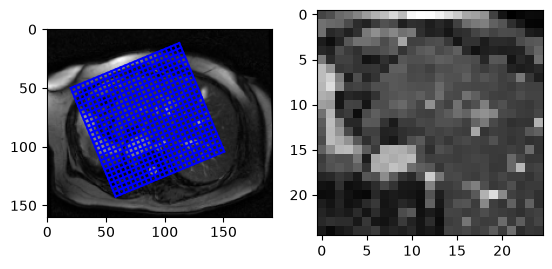

In [69]:
def interpolate(T):
    """ Resamples the 2D image T to a different image grid using cubic B-spline interpolation,
        and shows the result.
    """
  
    # define the image grid
    num_points = 25
    alpha = np.pi/8
    orig = (50, 20)
    X, Y = np.meshgrid(np.linspace(0, 100, num_points), 
                       np.linspace(0, 100, num_points), indexing='ij' )
    X1_interp = np.cos(alpha) * X - np.sin(alpha) * Y + orig[0]
    X2_interp = np.sin(alpha) * X + np.cos(alpha) * Y + orig[1]

    # illustrate the location of the image grid
    fig, ax = plt.subplots(1,2)
    ax[0].imshow(T, cmap='gray')
    for i in range(X1_interp.shape[0]):
        ax[0].plot(X2_interp[i,:], X1_interp[i,:], color='b')
    for i in range(X1_interp.shape[1]):
        ax[0].plot(X2_interp[:,i], X1_interp[:,i], color='b')

    # compute the interpolated image
    W = compute_W(T)
    T_interp = np.zeros_like(X1_interp)

    for row in range(X1_interp.shape[0]):
        for col in range(X1_interp.shape[1]):
            x1_interp, x2_interp = X1_interp[row, col], X2_interp[row, col]
            value = evaluate(W, x1_interp, x2_interp)
            T_interp[row, col] = value

    # show the interpolated image
    ax[1].imshow(T_interp, cmap='gray')

interpolate(T)